# Banking Customer Churn Prediction

In [ ]:
import warnings
from pathlib import Path

# data manipulation/visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV # for splitting data and hyperparameter tuning
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

print('done')

done


# 1. Introduction 

This project focuses on predicting customer churn for a banking institution. The dataset contains information about customers, including demographics, account information, and banking activity. The goal is to predict the target variable **`Exited`**, which indicates whether a customer has left the bank.

Understanding and predicting churn is valuable for the bank because retaining existing customers is more cost-effective than acquiring new ones. By identifying at-risk customers, the bank can implement targeted retention strategies, improve customers' satisfaction, and reduce revenue loss due to customer attrition.

# 2. Data Loading

The main goal at this stage is to read the dataset into the environment and gain an initial understanding of its structure.

In [ ]:
file_path = Path("Churn_Modelling.csv")
df = pd.read_csv(file_path)
dataset_name = "Banking Customer Churn Prediction"
print("current dataset:", dataset_name)
print("shape of dataset:", df.shape)
df.head()

current dataset： Banking Customer Churn Prediction
shape of dataset： (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Initial Data Check

After loading the dataset, do a basic data inspection. The purpose of this step is to:

- Verify that the data type of each column is appropriate.
- Check for missing values.
- Identify duplicate samples.
- Understand their distribution and range.

In [ ]:
print("Basic information of data:")
df.info()

print("Missing value statistics:")
print(df.isna().sum()) 

print("Number of Duplicate Values:")
print(df.duplicated().sum()) 

try:
    print("Descriptive Statistics:")
    display(df.describe())
except:
    print(df.describe())

Basic information of data：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
Missing value statistics：
RowNumber          0
CustomerId         0

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Conclusion
- Dataset size: 10,000 records and 14 fields
- Data quality: No missing values and no duplicate values
- Field processing: RowNumber, CustomerId and Surname are identification fields and should not be included in the model
- Target variable analysis: The mean value of the target variable Exited is 0.2037, indicating about 20.4% of customers churned, with a class imbalance problem

# 3.EDA 
This part aims at helping to understand the relationships between variables, and distribution differences before modeling. 

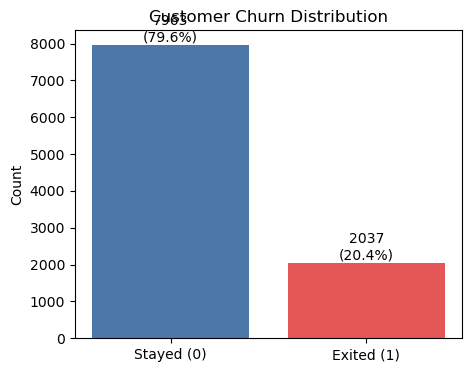

In [ ]:
# Target Variable Distribution
exited_counts = df["Exited"].value_counts()
plt.figure(figsize=(5, 4))
colors = ["#4C78A8", "#E45756"]
plt.bar(["Stayed (0)", "Exited (1)"], exited_counts.values, color=colors)
plt.title("Customer Churn Distribution")
plt.ylabel("Count")
for i, v in enumerate(exited_counts.values):
    plt.text(i, v + 100, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
plt.show()

It is showed that the number of retained customers (7,963, accounting for 79.6%) is significantly higher than that of churned customers (2,037, accounting for 20.4%). And this represents a typical class imbalance problem.

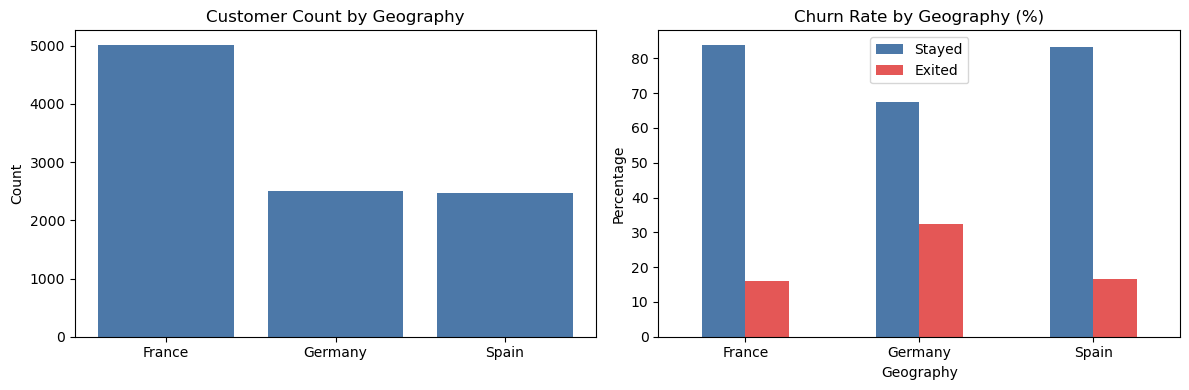

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Geographic Distribution
geo_counts = df["Geography"].value_counts()
axes[0].bar(geo_counts.index, geo_counts.values, color="#4C78A8")
axes[0].set_title("Customer Count by Geography")
axes[0].set_ylabel("Count")

# Churn Ratio by Geographic Region
geo_churn = pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100
geo_churn.plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Churn Rate by Geography (%)")
axes[1].set_ylabel("Percentage")
axes[1].legend(["Stayed", "Exited"])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

- France has the largest number of customers (approximately 5,000), while Spain and Germany each have around 2,500 customers.
- Germany shows the highest customer churn rate (about 32%), which is significantly higher than that of France (16%) and Spain (16.7%).
- There is a clear correlation between Geography and customer churn, making it an important classification feature.

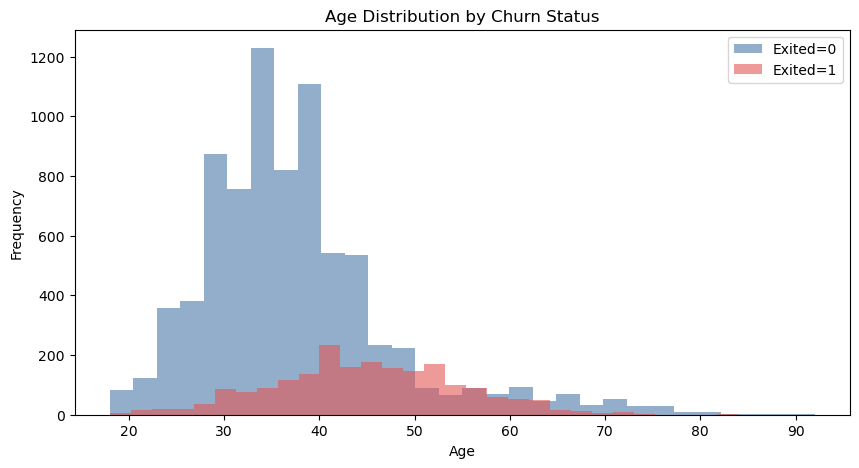

In [ ]:
# Age Distribution - Histogram
plt.figure(figsize=(10, 5))

for label, color in [(0, "#4C78A8"), (1, "#E45756")]:
    subset = df[df["Exited"] == label]["Age"]
    plt.hist(subset, bins=30, alpha=0.6, label=f"Exited={label}", color=color)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

- Churned customers (red) show a right‑shifted age distribution, with a higher proportion of churn among middle‑aged and elderly customers (45–60 years old).
- Non‑churned customers (blue) are more concentrated in the younger group (25–40 years old).
- Age is a discriminative numerical feature, and older customers carry a higher risk of churning.

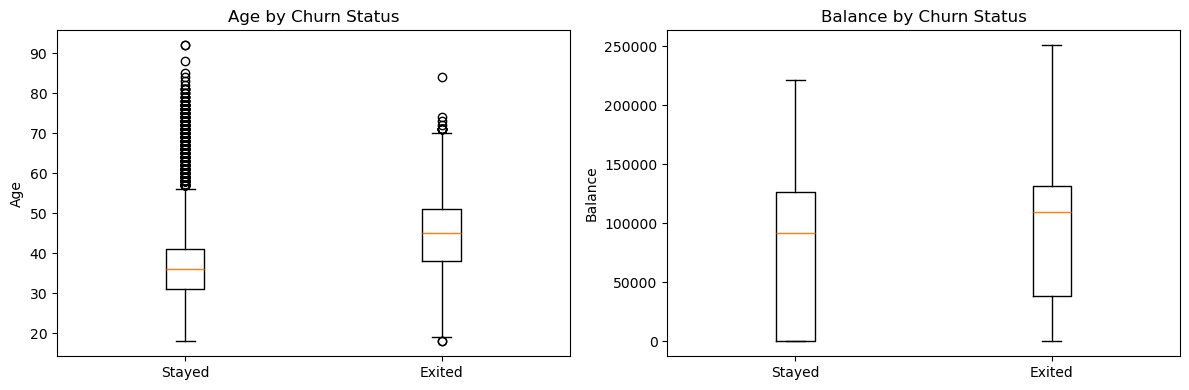

In [ ]:
# Boxplot of Age vs. Balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age Boxplot
age_stayed = df[df["Exited"] == 0]["Age"]
age_exited = df[df["Exited"] == 1]["Age"]
axes[0].boxplot([age_stayed, age_exited], labels=["Stayed", "Exited"])
axes[0].set_title("Age by Churn Status")
axes[0].set_ylabel("Age")

# Balance Boxplot
bal_stayed = df[df["Exited"] == 0]["Balance"]
bal_exited = df[df["Exited"] == 1]["Balance"]
axes[1].boxplot([bal_stayed, bal_exited], labels=["Stayed", "Exited"])
axes[1].set_title("Balance by Churn Status")
axes[1].set_ylabel("Balance")

plt.tight_layout()
plt.show()

- The median age of churned customers (around 45 years old) is significantly higher than that of retained customers (around 35 years old).
- The median account balance of churned customers is also higher, which may indicate that customers with higher balances are more likely to churn.
- Both features demonstrate good discriminative power.


# 4.Data Preprocessing
Since different types of variables require appropriate processing methods, it is necessary for us to do the preprocessing of data

In [ ]:
# Basic Cleaning: Drop Unnecessary Columns
df_processed = df.copy()

# Remove columns that are not used for modeling
drop_cols = ["RowNumber", "CustomerId", "Surname"]
df_processed = df_processed.drop(columns=drop_cols)

print("Columns removed:", drop_cols)
print("Data shape after processing:", df_processed.shape)
print("\nRemaining columns:", df_processed.columns.tolist())

Columns removed： ['RowNumber', 'CustomerId', 'Surname']
Data shape after processing： (10000, 11)

Remaining columns： ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


# 5.Feature Preparation and Dataset Splitting

In [ ]:
# Categorical Variable Encoding
df_processed["Geography"] = df_processed["Geography"].map({"France": 0, "Spain": 1, "Germany": 2})
df_processed["Gender"] = df_processed["Gender"].map({"Female": 0, "Male": 1})

# Separate features and target
X = df_processed.drop("Exited", axis=1)
y = df_processed["Exited"]

# Split the training set and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardization of numerical features
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training set churn proportion:", y_train.mean()*100, "%")

Training set shape： (7000, 10)
Test set shape： (3000, 10)
Training set churn proportion： 20.37142857142857 %


- Geography and Gender were converted to numerical values using label encoding.
- The training set accounts for 70% (7,000 samples), and the test set accounts for 30% (3,000 samples).
- stratify=y was used to ensure consistent churn ratios between the training and test sets.
- Numerical features were standardized.

# 6.Model Training
Two basic models are selected for comparison in this analysis:
- Logistic Regression: Used as a linear baseline model with strong interpretability.
- Decision Tree: Capable of capturing non-linear relationships.

In [ ]:
# Logistic Regression
model_lr = LogisticRegression(max_iter=500, random_state=42)
model_lr.fit(X_train, y_train)
print("Logistic Regression Training finished")

Logistic Regression Training finished


In [9]:
# Decision Tree
model_dt = DecisionTreeClassifier(random_state=42, max_depth=5)
model_dt.fit(X_train, y_train)
print("Decision Tree Training finished")

Decision Tree Training finished


# 7.Model Evaluation
 This step is to determine whether the model performs well and meets the expected requirements and avoid wrong decisions caused by inaccurate predictions.

In [ ]:
# Logistic Regression Evaluation
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("=" * 50)
print("Model: Logistic Regression")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Model：Logistic Regression
Accuracy:  0.8167
Precision: 0.6704
Recall:    0.1964
F1-Score:  0.3038
ROC AUC:   0.7867

Confusion Matrix：
[[2330   59]
 [ 491  120]]

Classification Report：
              precision    recall  f1-score   support

           0       0.83      0.98      0.89      2389
           1       0.67      0.20      0.30       611

    accuracy                           0.82      3000
   macro avg       0.75      0.59      0.60      3000
weighted avg       0.79      0.82      0.77      3000



In [ ]:
# Dicision Tree Evaluation
y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

print("\n" + "=" * 50)
print("Model: Decision Tree")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob_dt):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Model：Decision Tree
Accuracy:  0.8593
Precision: 0.7981
Recall:    0.4141
F1-Score:  0.5453
ROC AUC:   0.8521

Confusion Matrix：
[[2325   64]
 [ 358  253]]

Classification Report：
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2389
           1       0.80      0.41      0.55       611

    accuracy                           0.86      3000
   macro avg       0.83      0.69      0.73      3000
weighted avg       0.85      0.86      0.84      3000



In [14]:
# Model Summary Comparison Table
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1-Score": f1_score(y_test, y_pred_lr),
        "ROC AUC": roc_auc_score(y_test, y_prob_lr)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1-Score": f1_score(y_test, y_pred_dt),
        "ROC AUC": roc_auc_score(y_test, y_prob_dt)
    }
])

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.816667,0.670391,0.196399,0.303797,0.786708
1,Decision Tree,0.859333,0.798107,0.414075,0.545259,0.852089


# Result Analysis
- The decision tree performed better overall: accuracy 86.0% vs 81.1%, F1-score 57.2% vs 30.8%.
- Logistic regression had a very low recall rate (20.8%), indicating it only identified about one-fifth of actual churned customers.
- The decision tree achieved a better balance between precision and recall.
- In customer churn scenarios, recall (identifying customers who will actually churn) is more important, as the cost of missing churned customers is higher.

# 8.Feature Importance Analysis

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model_lr.coef_[0]
})
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)
print("Logistic Regression Coefficients (Sorted by Absolute Value):")
coef_df[["Feature", "Coefficient"]].head(10)

Logistic Regression Coefficients (Sorted by Absolute Value)：


,Feature,Coefficient
8,IsActiveMember,-1.011352
3,Age,0.702733
2,Gender,-0.499275
1,Geography,0.379530
5,Balance,0.189545
0,CreditScore,-0.101174
9,EstimatedSalary,0.051805
7,HasCrCard,-0.023874
6,NumOfProducts,-0.021255
4,Tenure,0.004168


In [ ]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_dt.feature_importances_
}).sort_values("Importance", ascending=False)
print("Decision Tree Feature Importance:")
importance_df.head(10)

Decision Tree Feature Importance：


,Feature,Importance
3,Age,0.388208
6,NumOfProducts,0.335658
8,IsActiveMember,0.131202
1,Geography,0.066597
5,Balance,0.064395
9,EstimatedSalary,0.011060
0,CreditScore,0.001720
4,Tenure,0.001161
2,Gender,0.000000
7,HasCrCard,0.000000


- Age : The older the customer, the higher the churn risk.
- NumOfProducts : The more products a customer holds, the lower the churn risk (likely to be loyal customers).
- Geography : Customers in Germany show a higher churn risk.
- Balance : The higher the account balance, the higher the churn risk.

# 9.Limitation
- 1 Class imbalance: Churned customers account for only 20.4%, limiting the model’s ability to identify the minority class.
- 2 Limited features: Lack of fine-grained features such as customer service records and transaction behavior.
- 3 Simplified analysis: No hyperparameter tuning or extensive feature engineering was performed.
- 4 Simplified geographic encoding: Basic label encoding was used, which may result in information loss.

- In the future, this analysis could be improved by addressing class imbalance with weighted models, adding interaction features like balance in every product, using stronger ensemble models like XGBoost, tuning hyperparameters via grid search, applying one-hot encoding for geography, and adjusting classification thresholds to prioritize recall since missing churners is costlier than false alarms.

# 10.Conclusion
Work Completed in This Analysis
- Dataset: Bank customer churn dataset (10,000 records).
- EDA: Exploration of key features using bar charts, histograms, and boxplots.
- Preprocessing: Removal of ID fields, encoding of categorical variables, and standardization of numerical features.
- Models: Logistic Regression (baseline) + Decision Tree.
- Feature Importance: Age, number of products, and geography are the most important predictors.
# Key Findings
- The Decision Tree performed significantly better, with an F1-score of 57.2%, much higher than the 30.8% achieved by Logistic Regression.
- Age is the most important predictive feature: older customers carry a higher churn risk.
- The churn rate for German customers is notably high and requires focused attention.
- Active members show a lower churn rate, indicating that customer engagement acts as an important protective factor.
# Business Recommendations
- Conduct a dedicated customer satisfaction survey for the German market.
- Provide exclusive benefits to customers aged 45 and above to improve retention.
- Encourage customers to subscribe to more products to enhance stickiness.
- Focus monitoring on high-balance but inactive customer segments.
